In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pyarrow

# configurar o notebook para exibir todas as colunas
pd.set_option('display.max_columns', None)

BASE ORIGINAL (https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

In [ ]:
#df_numeric = pd.read_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/statlog_german_credit_data/german.data-numeric', header=None, delim_whitespace=True)
#from ucimlrepo import fetch_ucirepo; statlog_german_credit_data = fetch_ucirepo(id=144); print(statlog_german_credit_data.metadata); print(statlog_german_credit_data.variables) 

# BASE TRATATADA PELA PENNSTATE UNIVERSITY 

(https://online.stat.psu.edu/stat857/node/216/)

In [2]:
dt = pd.read_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/german_credit.csv')
df = dt.copy()
df.head(1)

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,Guarantors,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1


In [3]:
# definir variavbeis categoricas
categorical_cols = ['Creditability','Account Balance', 'Payment Status of Previous Credit', 
                    'Purpose', 'Value Savings/Stocks', 'Length of current employment',
                    'Sex & Marital Status', 'Guarantors', 'Most valuable available asset',
                    'Concurrent Credits', 'Type of apartment', 'Occupation', 'Telephone', 'Foreign Worker']
df[categorical_cols] = df[categorical_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Creditability                      1000 non-null   category
 1   Account Balance                    1000 non-null   category
 2   Duration of Credit (month)         1000 non-null   int64   
 3   Payment Status of Previous Credit  1000 non-null   category
 4   Purpose                            1000 non-null   category
 5   Credit Amount                      1000 non-null   int64   
 6   Value Savings/Stocks               1000 non-null   category
 7   Length of current employment       1000 non-null   category
 8   Instalment per cent                1000 non-null   int64   
 9   Sex & Marital Status               1000 non-null   category
 10  Guarantors                         1000 non-null   category
 11  Duration in Current address        1000 non-

In [4]:
rename_dict = {
    "Account Balance": "acct_bal",
    "Duration of Credit (month)": "dur_months",
    "Payment Status of Previous Credit": "cred_hist",
    "Purpose": "purpose",
    "Credit Amount": "cred_amt",
    "Value Savings/Stocks": "savings",
    "Length of current employment": "emp_dur",
    "Instalment per cent": "inst_rate",
    "Sex & Marital Status": "pers_status",
    "Guarantors": "guarantors",
    "Duration in Current address": "res_dur",
    "Most valuable available asset": "property",
    "Age (years)": "age",
    "Concurrent Credits": "other_creds",
    "Type of apartment": "housing",
    "No of Credits at this Bank": "num_creds",
    "Occupation": "job",
    "No of dependents": "dependents",
    "Telephone": "phone",
    "Foreign Worker": "foreign_worker",
    "Creditability": "target"
}
df = df.rename(columns={col: rename_dict[col] for col in df.columns if col in rename_dict})
df.head(1)

,target,acct_bal,dur_months,cred_hist,purpose,cred_amt,savings,emp_dur,inst_rate,pers_status,guarantors,res_dur,property,age,other_creds,housing,num_creds,job,dependents,phone,foreign_worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1


In [6]:
df.to_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_renamed_cols.csv', sep=';', index=False)

## SALVA E CARREGA A BASE RENOMEADA

In [5]:
#df.to_pickle('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_renamed.pkl')
df = pd.read_pickle('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_renamed.pkl')

SEPARA AS VARIAVEIS NUMERICAS E CATEGORICAS

In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
numerical_cols

['dur_months',
 'cred_amt',
 'inst_rate',
 'res_dur',
 'age',
 'num_creds',
 'dependents']

DISTRIBUICAO DAS VARIAVEIS NUMERICAS - HISTOGRAMAS

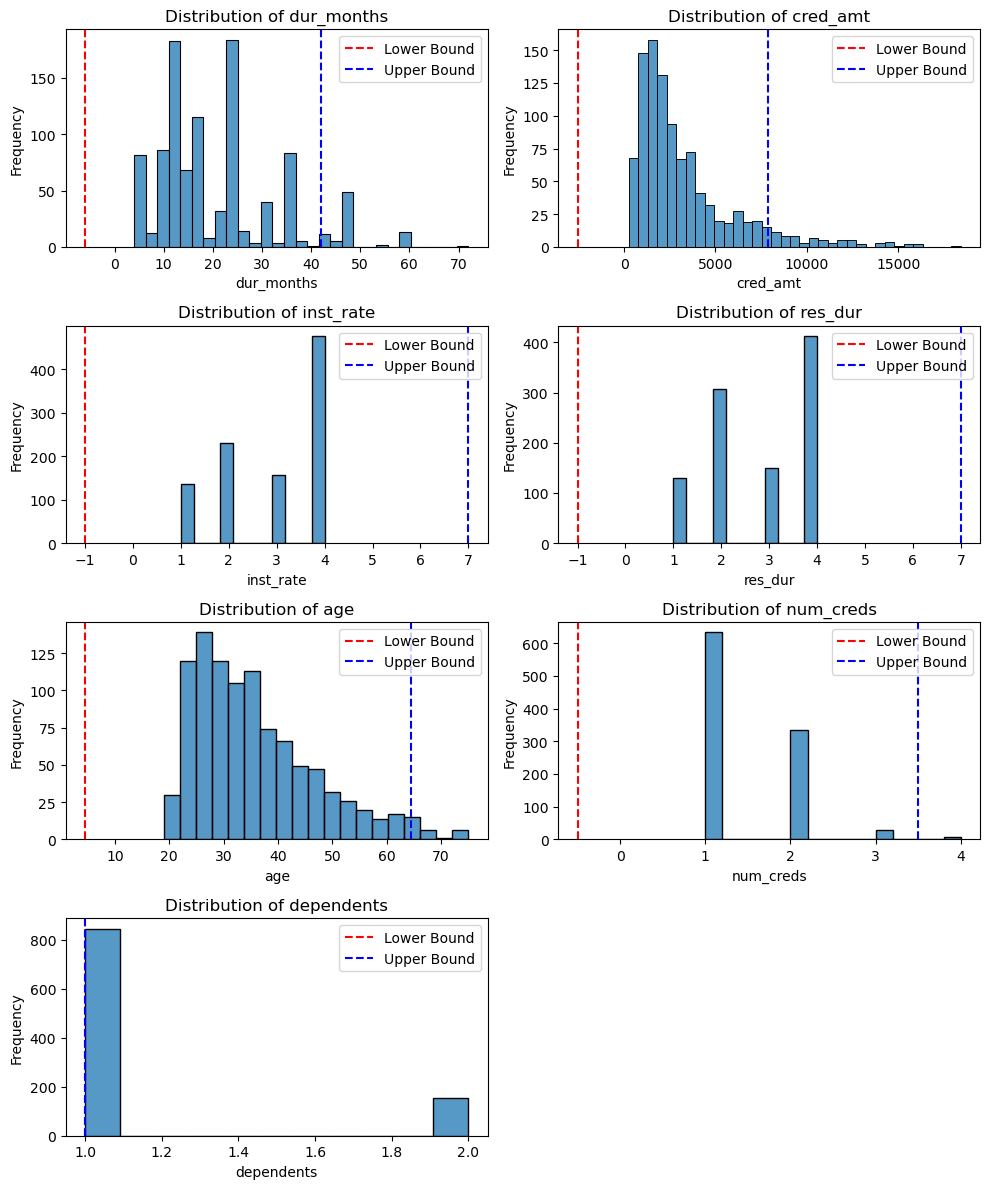

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 2
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))

for idx, col in enumerate(numerical_cols):
    q25, q75 = np.percentile(df[col], 25), np.percentile(df[col], 75)
    iqr = q75 - q25
    cutt_off = 1.5 * iqr
    lower_bound = q25 - cutt_off
    upper_bound = q75 + cutt_off
    
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    sns.histplot(df[col], ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

    # Adiciona linhas verticais para os limites de outlier
    ax.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    ax.axvline(upper_bound, color='blue', linestyle='--', label='Upper Bound')
    ax.legend()

# Remove empty subplots if any
for idx in range(len(numerical_cols), n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()
    


### DATA SPLIT

In [7]:
# Separacao do dataframe entre variaveis preditoras e variavel resposta (Creditability) e treino (70%) e teste (30%) 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### DATA CLEANING

- identify and remove column variables that only have a single value.
- identify and consider column variables with very few unique values.
- identify and remove rows that contain duplicate observations.

In [ ]:
# 1. Remover colunas com valores únicos

from sklearn.base import BaseEstimator, TransformerMixin

class RemoveSingleValueColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        counts = X.nunique()
        self.cols_to_keep_ = [col for col in X.columns if counts[col] > 1]
        return self
    
    def transform(self, X):
        return X[self.cols_to_keep_]


# 2. Remover variáveis com poucos valores (ex.: < 1% do total de linhas)

class RemoveLowCardinalityColumns(BaseEstimator, TransformerMixin):
    def __init__(self, min_pct=1.0):
        self.min_pct = min_pct
    
    def fit(self, X, y=None):
        n_rows = X.shape[0]
        counts = X.nunique()
        self.cols_to_keep_ = [
            col for col in X.columns 
            if (counts[col] / n_rows * 100) >= self.min_pct
        ]
        return self
    
    def transform(self, X):
        return X[self.cols_to_keep_]


# 3. Remover outliers com IQR
    # Aqui é preciso cuidado: no treino ajustamos limiares (Q1, Q3, IQR).
    # No teste, aplicamos os mesmos limites calculados no treino.

class MarkOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, factor=1.5):
        self.columns = columns
        self.factor = factor
    
    def fit(self, X, y=None):
        self.bounds_ = {}
        cols = self.columns if self.columns is not None else X.columns
        for col in cols:
            q25, q75 = np.percentile(X[col], 25), np.percentile(X[col], 75)
            iqr = q75 - q25
            cut_off = self.factor * iqr
            lower, upper = q25 - cut_off, q75 + cut_off
            self.bounds_[col] = (lower, upper)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col, (lower, upper) in self.bounds_.items():
            mask = (X_copy[col] >= lower) & (X_copy[col] <= upper)
            X_copy.loc[~mask, col] = np.nan  # só marca como NaN
        return X_copy


In [ ]:
from sklearn.pipeline import Pipeline

# Pipeline de limpeza
cleaning_pipeline = Pipeline(steps=[
    ("remove_single_value", RemoveSingleValueColumns()),
    ("remove_low_cardinality", RemoveLowCardinalityColumns(min_pct=1.0)),
    ("remove_outliers", RemoveOutliersIQR(columns=numerical_cols, factor=1.5))
])

# Ajustar apenas no treino
X_train_clean = cleaning_pipeline.fit_transform(X_train)

# Aplicar no teste usando os parâmetros do treino
X_test_clean = cleaning_pipeline.transform(X_test)


# LIMPEZA DOS DADOS

In [8]:
# imports
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -------------------------------
# 0) Identificar variáveis numéricas (use X_train para evitar leakage)
# -------------------------------
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numerical_cols

['dur_months',
 'cred_amt',
 'inst_rate',
 'res_dur',
 'age',
 'num_creds',
 'dependents']

# limpeza manual

IDENTIFICAR E REMOVER COLUNAS COM VALORES UNICOS

In [9]:
counts = df[numerical_cols].nunique()
to_del = [col for col in df[numerical_cols].columns if counts[col] == 1]
to_del
#df.drop(to_del, axis=1, inplace=True)

[]

IDENTIFICAR E REMOVER VARIAVEIS COM POUCOS VALORES

In [10]:
for i in df[numerical_cols].columns:
    num = len(df.loc[:, i].unique())
    percentage = float(num) / df.shape[0] * 100
    #if percentage < 1:                             # ajustar o valor de corte
    print('%s, %d, %.1f%%' % (i, num, percentage))

counts2 = df[numerical_cols].nunique()
to_del2 = [col for col in df[numerical_cols].columns if (float(counts2[col])/df.shape[0]*100) < 1]
print()
print(f"Para deletar (under 1%): {to_del2}")
#df.drop(to_del2, axis=1, inplace=True)


dur_months, 33, 3.3%
cred_amt, 923, 92.3%
inst_rate, 4, 0.4%
res_dur, 4, 0.4%
age, 53, 5.3%
num_creds, 4, 0.4%
dependents, 2, 0.2%

Para deletar (under 1%): ['inst_rate', 'res_dur', 'num_creds', 'dependents']


IDENTIFICACAO E REMOCAO DE OUTLIERS

- Metodo intervalo interquartil

In [11]:
def remove_outliers_iqr(variavel):
    q25, q75 = np.percentile(variavel, 25), np.percentile(variavel, 75)
    iqr = q75 - q25
    cutt_off = 1.5 * iqr
    lower_bound = q25 - cutt_off
    upper_bound = q75 + cutt_off
#Retorna apenas os valores dentro dos limites (nao outliers)
    return variavel[(variavel >= lower_bound) & (variavel <= upper_bound)]

df_no_outliers = df.copy()

for col in numerical_cols:
#Remove os outliers da coluna usando a função definida acima
    df_no_outliers[col] = remove_outliers_iqr(df_no_outliers[col])

#Remove todas as linhas que ficaram com valores NaN (ou seja, que tinham outliers em alguma coluna)
#e reseta o indice do DataFrame
df_no_outliers = df_no_outliers.dropna().reset_index(drop=True)


# Pipelline completo

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# -------------------------------
# 1) Transformador: remover colunas com único valor
# -------------------------------
class RemoveSingleValueColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        # columns: optional subset; se None, usa todas as colunas do X passado
        self.columns = columns

    def fit(self, X, y=None):
        cols = self.columns if self.columns is not None else X.columns
        counts = X[cols].nunique()
        self.cols_to_keep_ = [c for c in cols if counts[c] > 1]
        return self

    def transform(self, X):
        # mantém a ordem original das colunas guardadas
        return X.loc[:, [c for c in self.cols_to_keep_ if c in X.columns]].copy()

# -------------------------------
# 2) Transformador: remover colunas com baixa cardinalidade (< min_pct % de linhas únicas)
# -------------------------------
class RemoveLowCardinalityColumns(BaseEstimator, TransformerMixin):
    def __init__(self, min_pct=1.0, columns=None):
        self.min_pct = min_pct
        self.columns = columns

    def fit(self, X, y=None):
        cols = self.columns if self.columns is not None else X.columns
        n_rows = X.shape[0]
        counts = X[cols].nunique()
        self.cols_to_keep_ = [c for c in cols if (counts[c] / n_rows * 100) >= self.min_pct]
        return self

    def transform(self, X):
        return X.loc[:, [c for c in self.cols_to_keep_ if c in X.columns]].copy()

# -------------------------------
# 3) Transformador: marcar outliers por IQR (marca como NaN; NÃO remove linhas)
#    - fit: calcula q1,q3,iqr no treino
#    - transform: aplica os mesmos limites e substitui outliers por NaN
# -------------------------------
class MarkOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, factor=1.5):
        self.columns = columns
        self.factor = factor

    def fit(self, X, y=None):
        cols = self.columns if self.columns is not None else X.columns
        self.bounds_ = {}
        for col in cols:
            # se a coluna não existir em X, pula
            if col not in X.columns:
                continue
            q25 = np.percentile(X[col].dropna(), 25)
            q75 = np.percentile(X[col].dropna(), 75)
            iqr = q75 - q25
            cut_off = self.factor * iqr
            lower, upper = q25 - cut_off, q75 + cut_off
            self.bounds_[col] = (lower, upper)
        return self

    def transform(self, X):
        X_out = X.copy()
        for col, (lower, upper) in self.bounds_.items():
            if col not in X_out.columns:
                continue
            mask = (X_out[col] >= lower) & (X_out[col] <= upper)
            X_out.loc[~mask, col] = np.nan  # marca como NaN (não remove linhas)
        return X_out

# -------------------------------
# 4) Imputador que retorna DataFrame (mantém colnames e index)
# -------------------------------
class DataFrameImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mean'):
        self.strategy = strategy
        self.imputer = SimpleImputer(strategy=self.strategy)

    def fit(self, X, y=None):
        # X should be DataFrame
        self.imputer.fit(X)
        self.columns_ = X.columns.tolist()
        return self

    def transform(self, X):
        arr = self.imputer.transform(X)
        return pd.DataFrame(arr, columns=self.columns_, index=X.index)

# -------------------------------
# 5) Montar o pipeline de limpeza para as colunas numéricas
#    Ordem recomendada:
#      1) remover colunas constantes
#      2) remover colunas de baixa cardinalidade
#      3) marcar outliers (IQR)
#      4) imputar NaNs resultantes (inclui NaNs originais e os das marcações)
# -------------------------------
cleaning_pipeline_num = Pipeline(steps=[
    ('rm_single', RemoveSingleValueColumns(columns=continuos_cols)),
    ('rm_lowcard', RemoveLowCardinalityColumns(min_pct=1.0, columns=None)),  # columns=None permite reaplicar nas colunas filtradas
    ('mark_outliers', MarkOutliersIQR(columns=None, factor=1.5)),
    ('imputer', DataFrameImputer(strategy='mean'))
])

# -------------------------------
# 6) Uso (Fluxo recomendado — NÃO remover linhas)
# -------------------------------
# Ajusta só no treino
X_train_num_clean = cleaning_pipeline_num.fit_transform(X_train[numerical_cols])

# Aplica no teste com mesmos parâmetros (sem recalcular)
X_test_num_clean = cleaning_pipeline_num.transform(X_test[numerical_cols])

# Reconciliar com colunas não-numéricas (mantendo índices)
X_train_other = X_train.drop(columns=numerical_cols)
X_test_other = X_test.drop(columns=numerical_cols)

X_train_clean = pd.concat([X_train_other.reset_index(drop=True), X_train_num_clean.reset_index(drop=True)], axis=1)
X_test_clean  = pd.concat([X_test_other.reset_index(drop=True),  X_test_num_clean.reset_index(drop=True)], axis=1)

# y_train e y_test permanecem inalterados neste fluxo